# Step 5 — SHAP Interpretability
### gametheory-sweetcrete

Step 1 used Shapley values (from cooperative **game theory**) to *select* features. Here we
apply them to the **trained model** to explain its predictions — accuracy is not enough;
a mix-design tool must be able to say *why*.

SHAP treats each feature as a "player" in a game and fairly distributes the prediction
(relative to the average) among them. We produce:

1. **Beeswarm** — global: which features matter and in which direction
2. **Dependence plots** — how a feature's effect changes across its range
3. **Waterfall** — local: a full explanation of one individual prediction

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import numpy as np, joblib, shap
import matplotlib.pyplot as plt

%matplotlib inline
p=Path.cwd()
while not (p/"src").exists() and p!=p.parent: p=p.parent
ROOT=p; FIG=ROOT/"results"/"figures"; FIG.mkdir(parents=True,exist_ok=True)
sys.path.insert(0,str(ROOT/"src"))
from preprocessing import get_split, SELECTED_FEATURES

X_train,X_test,y_train,y_test = get_split()
pipe = joblib.load(ROOT/"models"/"best_model.joblib")
scaler, rf = pipe.named_steps["scaler"], pipe.named_steps["model"]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(scaler.transform(X_train))
base_value = float(np.array(explainer.expected_value).ravel()[0])
print("SHAP values:", shap_values.shape, "| base value (avg prediction):", round(base_value,2), "MPa")

SHAP values: (142, 5) | base value (avg prediction): 27.53 MPa


## 1. Global explanation — beeswarm
Each dot is one mix. Position = effect on the predicted strength (MPa); colour = whether
that feature's value was high (red) or low (blue) for that mix.

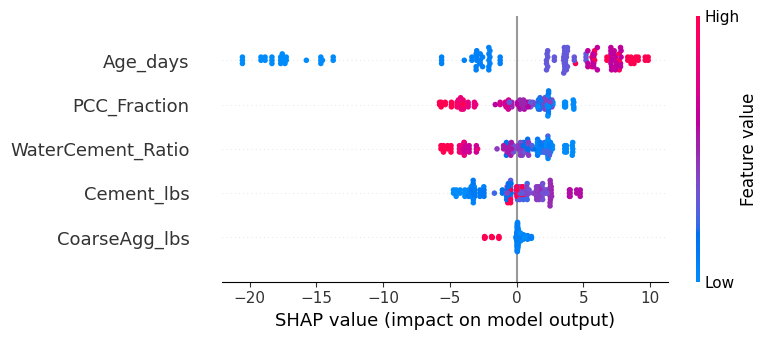

In [2]:
shap.summary_plot(shap_values, X_train, feature_names=SELECTED_FEATURES, show=False)
plt.tight_layout(); plt.savefig(FIG/"shap_beeswarm.png", dpi=150, bbox_inches="tight"); plt.show()

**Reading it:** high `Age_days` (red) strongly pushes strength *up*; high `PCC_Fraction`
(red) pushes it *down*; high `WaterCement_Ratio` (red) pushes *down* — textbook Abrams'
law. The model has learned real concrete physics, not arbitrary patterns.

## 2. Dependence — how age and PCC drive predictions
The shape of each feature's effect across its full range.

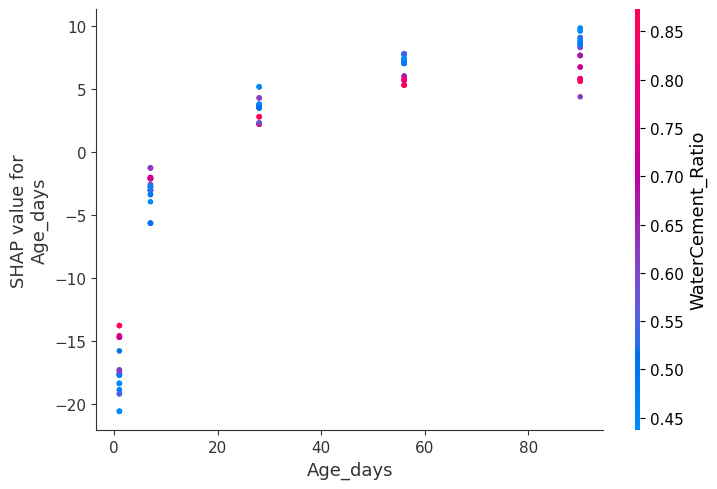

In [3]:
shap.dependence_plot("Age_days", shap_values, X_train, feature_names=SELECTED_FEATURES, show=False)
plt.tight_layout(); plt.savefig(FIG/"shap_dependence_age.png", dpi=150, bbox_inches="tight"); plt.show()

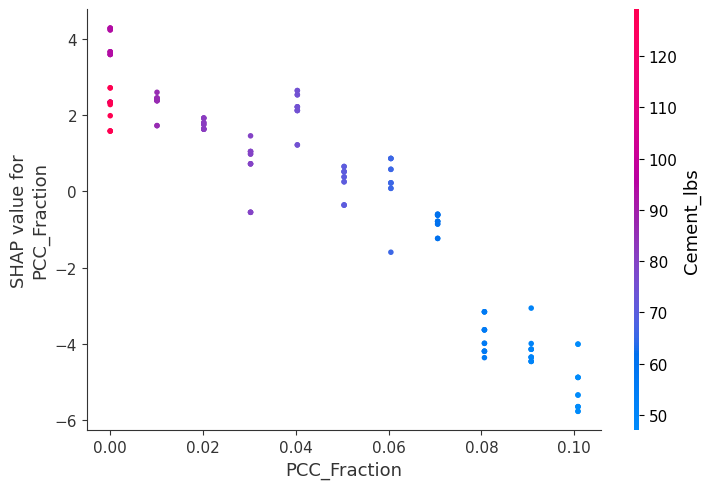

In [4]:
shap.dependence_plot("PCC_Fraction", shap_values, X_train, feature_names=SELECTED_FEATURES, show=False)
plt.tight_layout(); plt.savefig(FIG/"shap_dependence_pcc.png", dpi=150, bbox_inches="tight"); plt.show()

## 3. Local explanation — one mix, fully explained
A waterfall starts at the average prediction and shows how each feature moves *this*
specific mix's predicted strength up or down to the final value.

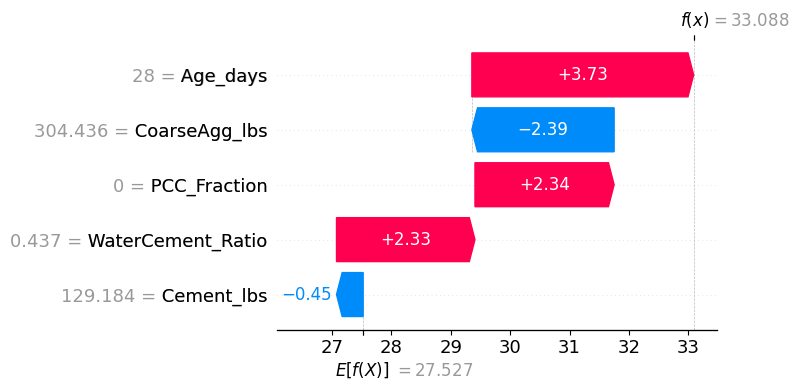

This mix: {'Age_days': 28.0, 'Cement_lbs': 129.184, 'PCC_Fraction': 0.0, 'WaterCement_Ratio': 0.436648501362398, 'CoarseAgg_lbs': 304.436}
Actual strength: 33.7 MPa


In [5]:
i = 0
expl_one = shap.Explanation(values=shap_values[i], base_values=base_value,
                            data=X_train.iloc[i].values, feature_names=SELECTED_FEATURES)
shap.plots.waterfall(expl_one, show=False)
plt.tight_layout(); plt.savefig(FIG/"shap_waterfall_example.png", dpi=150, bbox_inches="tight"); plt.show()
print("This mix:", X_train.iloc[i].to_dict())
print("Actual strength:", round(float(y_train.iloc[i]),1), "MPa")

## Takeaways

- **The model is interpretable, not a black box.** Every prediction decomposes into fair,
  additive feature contributions — exactly what an engineer (or reviewer) needs to trust it.
- **It learned real physics:** age increases strength; PCC replacement and high water/cement
  ratio decrease it. This corroborates the EDA and the concrete-science literature.
- These SHAP figures are paper- and poster-ready explanation artifacts.

**Next:** Step 6 — game-theoretic mix optimization: search recipes to maximize PCC
(sustainability) while meeting a target strength, using the model as the objective.